<a href="https://colab.research.google.com/github/tavish-1721/Tavish-/blob/main/PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

using device cpu
Epoch 1/5, Loss: 317.1716
Epoch 2/5, Loss: 143.0426
Epoch 3/5, Loss: 98.9896
Epoch 4/5, Loss: 75.2588
Epoch 5/5, Loss: 58.6568
Test Accuracy: 97.68%
Model saved as mnist_model.pth


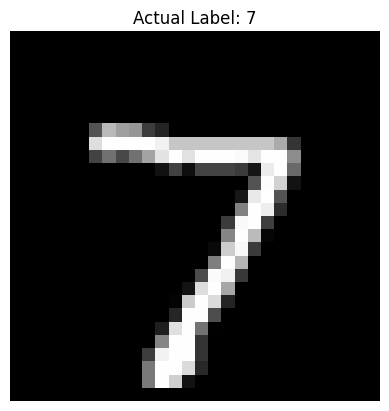

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

#Section 1 — Setup
device = "cuda" if torch.cuda.is_available() else "cpu" #Checks if your computer has a GPU. If yes uses GPU (faster), otherwise uses CPU. Your computer printed cpu so it runs on CPU.
print("using device", device)

#Section 2 — Data loading,Downloads 70,000 handwritten digit images from the internet
transform = transforms.ToTensor() # converts image pixels from 0-255 to 0.0-1.0
train_data = MNIST(root="data", train=True,  download=True, transform=transform)#60,000 images  (model learns from these)
test_data  = MNIST(root="data", train=False, download=True, transform=transform)#10,000 images  (model is tested on these, never seen before)

#Section 3 — DataLoader:60,000 images ÷ 64 per batch = 937 batches per epoch
train_loader = DataLoader(train_data, batch_size=64, shuffle=True) #shuffle=True  → random order each epoch (prevents memorizing order)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)# fixed order for testing (doesn't matter for evaluation)

#Section 4 — The model,Each MNIST image is 28×28 pixels = 784 numbers
class DigitModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28*28, 128),  #    784 numbers (flattened image), learns 128 features from pixels
            nn.ReLU(), # removes negative values
            nn.Linear(128, 10) #converts to 10 scores (one per digit 0-9)
        )

    def forward(self, x):
        return self.net(x)


#step5-10 scores — highest score = predicted digit
model     = DigitModel().to(device) # creates the network with random weights
loss_fn   = nn.CrossEntropyLoss() #measures how wrong the prediction is for classification
optimizer = optim.Adam(model.parameters(), lr=0.001)#Adam-updates weights to reduce the loss
epochs = 5

#Section 6 — Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.view(images.size(0), -1).to(device) #flattens [64,28,28] → [64,784]
        labels = labels.to(device)

        optimizer.zero_grad() #clears old gradients
        outputs = model(images) # forward pass, get predictions
        loss    = loss_fn(outputs, labels) # measure how wrong predictions are
        loss.backward() # compute gradients
        optimizer.step() #update weights to be less wrong

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

#Section 7 — Testing:
model.eval() #switches off training behaviour
correct = 0
total   = 0

with torch.no_grad():#no gradient tracking needed
    for images, labels in test_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        outputs     = model(images)
        predictions = outputs.argmax(dim=1) #picks the digit with highest score as prediction

        correct += (predictions == labels).sum().item() # calculates final accuracy percentage
        total   += labels.size(0)

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

#Section 8 — Save and visualize:
torch.save(model.state_dict(), "mnist_model.pth") #saves learned weights to disk
print("Model saved as mnist_model.pth")

index = 0
image, true_label = test_data[index] #picks one image from test set

plt.imshow(image.squeeze(), cmap="gray") #removes extra dimension [1,28,28] → [28,28]
plt.title(f"Actual Label: {true_label}")
plt.axis("off")
plt.show()

image_flat = image.view(1, -1).to(device)

with torch.no_grad():
    output          = model(image_flat)